# This notebook is used to determine the sensitivity matrix from CWFS data looking at both tip/tilt and decentering
## This is for data taken on 2021-06-08
### It first finds the pairs of CWFS images in the EFD
### It then fits the data a reports the zernikes
### Then plots the relationships and fits a slope for the matrix

In [1]:
import asyncio 
import matplotlib

import numpy as np
import pandas as pd

from matplotlib import pylab as plt
from astropy.time import Time, TimeDelta

from lsst_efd_client import EfdClient, resample

%matplotlib inline

In [2]:
#efd_client = EfdClient('summit_efd')
efd_client = EfdClient('ldf_stable_efd') 

### Find CWFS pairs
Query for all the `endReadout` events on the timespan of the night.

In [3]:
# define axis you're interested in

In [12]:
axis='y'
if axis == 'u':
    t1 = Time("2021-06-09T05:01:30", format='isot', scale='tai')
    t2 = Time("2021-06-09T05:21:44", format='isot', scale='tai')
if axis == 'v':
    t1 = Time("2021-06-09T05:21:44", format='isot', scale='tai')
    t2 = Time("2021-06-09T05:41:44", format='isot', scale='tai')
if axis == 'x':
    t1 = Time("2021-06-09T05:41:44", format='isot', scale='tai')
    t2 = Time("2021-06-09T06:04:44", format='isot', scale='tai')
if axis == 'y':
    t1 = Time("2021-06-09T06:01:44", format='isot', scale='tai')
    t2 = Time("2021-06-09T06:41:44", format='isot', scale='tai')

In [13]:
end_readout = await efd_client.select_time_series("lsst.sal.ATCamera.logevent_endReadout", 
                                           ["imageName", "requestedExposureTime", "additionalKeys", "additionalValues"], t1, t2)

Now match each entry. For each `i` item with `intra` in the name, there must be an `i+1` with `extra` otherwise it is not a pair. 
A pair also has the same groupID
The image before the pair is an in-focus image.

In [14]:
intra_images = []
extra_images = []
in_focus_images = []
intra_times = []
extra_times = []
in_focus_times = []
intra_exptimes = []
extra_exptimes = []
in_focus_exptimes = []

i = 0
npairs = 0
nmiss = 0

while i < len(end_readout)-2:
    intra = end_readout['imageName'][i]
    extra = end_readout['imageName'][i+1]
    in_focus = end_readout['imageName'][i-1]
    
    #skip known bad files
    if intra == 'AT_O_20200218_000179' and extra == 'AT_O_20200218_000180':
        i+=2
        continue
    group_id=(end_readout.additionalValues[i])[0:25]
    group_id_next=(end_readout.additionalValues[i+1])[0:25]
    group_id_previous=(end_readout.additionalValues[i+2])[0:25] # this is horrible, but looks for the in-focus image
    image_type=(end_readout.additionalValues[i])[26::]
    image_type_previous=(end_readout.additionalValues[i-1])[26::]
    if ((group_id_next == group_id) and 
        (group_id_next != group_id_previous) and
        (image_type == 'ENGTEST' and image_type_previous == 'OBJECT')):
        
        print(f"Got a pair: {intra} x {extra}, with in-focus of {in_focus}")
        intra_images.append(intra)
        extra_images.append(extra)
        in_focus_images.append(in_focus)
        intra_times.append(end_readout.index[i])
        extra_times.append(end_readout.index[i+1])
        in_focus_times.append(end_readout.index[i-1])
        intra_exptimes.append(end_readout['requestedExposureTime'][i])
        extra_exptimes.append(end_readout['requestedExposureTime'][i+1])
        in_focus_exptimes.append(end_readout['requestedExposureTime'][i-1])
        i+=2
        npairs+=1
    else:
#         print(f"No Match: {intra} x {extra}")
        nmiss+=1
        i+=1

print(f"Got {npairs} pairs and {nmiss} misses.")

Got a pair: AT_O_20210608_000454 x AT_O_20210608_000455, with in-focus of AT_O_20210608_000453
Got a pair: AT_O_20210608_000457 x AT_O_20210608_000458, with in-focus of AT_O_20210608_000456
Got a pair: AT_O_20210608_000460 x AT_O_20210608_000461, with in-focus of AT_O_20210608_000459
Got a pair: AT_O_20210608_000463 x AT_O_20210608_000464, with in-focus of AT_O_20210608_000462
Got a pair: AT_O_20210608_000467 x AT_O_20210608_000468, with in-focus of AT_O_20210608_000466
Got a pair: AT_O_20210608_000470 x AT_O_20210608_000471, with in-focus of AT_O_20210608_000469
Got a pair: AT_O_20210608_000473 x AT_O_20210608_000474, with in-focus of AT_O_20210608_000472
Got 7 pairs and 11 misses.


In [15]:
# Create numpy data structure to hold items of interest
match_data = np.zeros(npairs, dtype=[('intra', '<U35'), 
                                     ('extra', '<U35'),
                                     ('in_focus', '<U35'),
                                     ('az', float), 
                                           ('el', float), 
                                           ('rot_pos', float),
                                           ('x', float), 
                                           ('y', float), 
                                           ('z', float), 
                                           ('u', float), 
                                           ('v', float), 
                                           ('w', float), 
                                     ('m1_pressure', float),
                                     ('dz', float), # don't know what this is anymore
                                    ('off_u', float),
                                    ('off_u_cumul', float),])

In [16]:
# Populate the data structure from the pairs found above
off_u_cumul = 1/60. # started with a 1 arcmin offset before applying another for the first image
prev_timestamp=Time("2020-06-09T05:01:30", format='isot', scale='tai')
for i in range(npairs):
    
    # Determine time stamps for searching for metadata
    # include ability to correct for TAI if required, but set to zero for the moment

#     t1 = Time(intra_times[i], scale='tai') - TimeDelta(intra_exptimes[i], format='sec', scale='tai') 
    t1 = Time(in_focus_times[i], scale='tai') - TimeDelta(in_focus_exptimes[i], format='sec', scale='tai')    
    #- TimeDelta(180., format='sec', scale='tai')
    t2 = Time(extra_times[i], scale='tai') - TimeDelta(2., format='sec', scale='tai')

    azel = await efd_client.select_time_series("lsst.sal.ATMCS.mount_AzEl_Encoders", 
                                               ["elevationCalculatedAngle99", "azimuthCalculatedAngle99"], t1, t2)
    
    rotator = await efd_client.select_time_series("lsst.sal.ATMCS.mount_Nasmyth_Encoders",
                                                  ["nasmyth2CalculatedAngle99"], t1, t2)

    hexapod_vals = await efd_client.select_time_series("lsst.sal.ATHexapod.positionStatus", 
                                           ["reportedPosition0", "reportedPosition1", "reportedPosition2",
                                           "reportedPosition3", "reportedPosition4", "reportedPosition5"], t1 , t2)

    m1_pressure = await efd_client.select_time_series("lsst.sal.ATPneumatics.m1AirPressure",
                                                  ["pressure"], t1, t2)
    
#     offset = await efd_client.select_time_series("lsst.sal.ATAOS.cmd_",
#                                                  ["hexapod_x", "hexapod_y", "hexapod_z", "hexapod_u", "hexapod_v", "hexapod_w"], t1, t2)
    cmd_offset = await efd_client.select_time_series("lsst.sal.ATAOS.command_offset",
                                                 ["u", "v", "w", "x", "y", "z"], t1 - TimeDelta(300., format='sec', scale='tai'), t1) 

    
    rot_pos = np.mean(rotator['nasmyth2CalculatedAngle99'])
    el = np.mean(azel['elevationCalculatedAngle99'])
    az = np.mean(azel['azimuthCalculatedAngle99'])
    
    # Take median hexapod position over the time interval
    x = hexapod_vals['reportedPosition0'].median()
    y = hexapod_vals['reportedPosition1'].median()
    z = hexapod_vals['reportedPosition2'].median()
    u = hexapod_vals['reportedPosition3'].median()
    v = hexapod_vals['reportedPosition4'].median()
    w = hexapod_vals['reportedPosition5'].median()
    
    # this isn't working... I want to get the sum of the offsets since whatever the offset corresponding to the last offset was 
    # For the moment we'll just use the hexapod positions
    ind=np.argmin(abs(in_focus_times[i]-cmd_offset['u'].index))
    off_u = cmd_offset['u'][ind]
    if cmd_offset['u'].index[ind] != prev_timestamp and cmd_offset['u'][ind] != 0.0:
        print(f'prev is {prev_timestamp}')
        print(cmd_offset['u'].index[ind]) 
        print(cmd_offset['u'])
        off_u_cumul += cmd_offset['u'][ind]
        prev_timestamp = cmd_offset['u'].index[ind]
    else:
        print(f'prev is {prev_timestamp}')
        print(cmd_offset['u'].index[ind])
        print(cmd_offset['u'][ind])
        print(cmd_offset['u'])
    
    m1 = np.mean(m1_pressure['pressure'])
    dz = np.nan #round((offset['hexapod_z'][-1] - offset['hexapod_z'][-2])/2.,3)
    #print(cmd_offset['u'])
    print(f'{t1},{t2},{intra_images[i]}, {extra_images[i]}, {in_focus_images[i]}, {az:0.3f}, {el:0.3f}, {rot_pos:0.3f}, {x:0.3f}, {y:0.3f}, {z:0.3f}, {u:0.3f}, {v:0.3f}, {w:0.3f}, {dz}, {off_u:0.3f}, {off_u_cumul:0.3f}')
    match_data[i] = (f"{intra_images[i]}.fits", f"{extra_images[i]}.fits", f"{in_focus_images[i]}.fits", az, el, rot_pos, x, y, z, u, v, w, m1, dz, off_u, off_u_cumul)

prev is 2020-06-09T05:01:30.000
2021-06-09 06:03:05.513000+00:00
0
2021-06-09 05:58:30.394000+00:00    0
2021-06-09 05:58:58.059000+00:00    0
2021-06-09 05:59:25.519000+00:00    0
2021-06-09 05:59:41.179000+00:00    0
2021-06-09 06:00:40.300000+00:00    0
2021-06-09 06:01:07.467000+00:00    0
2021-06-09 06:01:34.575000+00:00    0
2021-06-09 06:01:50.231000+00:00    0
2021-06-09 06:03:05.513000+00:00    0
Name: u, dtype: int64
2021-06-09 06:03:29.142000,2021-06-09 06:05:15.781000,AT_O_20210608_000454, AT_O_20210608_000455, AT_O_20210608_000453, 127.148, 56.435, -38.417, -5.346, 0.943, 0.414, 0.350, 0.220, -0.000, nan, 0.000, 0.017
prev is 2020-06-09T05:01:30.000
2021-06-09 06:05:36.801000+00:00
0
2021-06-09 06:01:07.467000+00:00    0
2021-06-09 06:01:34.575000+00:00    0
2021-06-09 06:01:50.231000+00:00    0
2021-06-09 06:03:05.513000+00:00    0
2021-06-09 06:04:23.273000+00:00    0
2021-06-09 06:04:49.801000+00:00    0
2021-06-09 06:05:17.797000+00:00    0
2021-06-09 06:05:36.801000+0

In [17]:
# out = efd_client.rendezvous_dataframes(left, cmd_offset, direction='backward', tolerance=pandas.Timedelta(days=20), **kwargs):
# print(f'blah {cmd_offset['u'].index[ind]}') #why doesn't this work?!?

In [18]:
# Convert to dataframe
df = pd.DataFrame(match_data)

In [19]:
df

,intra,extra,in_focus,az,el,rot_pos,x,y,z,u,v,w,m1_pressure,dz,off_u,off_u_cumul
0,AT_O_20210608_000454.fits,AT_O_20210608_000455.fits,AT_O_20210608_000453.fits,127.148095,56.434829,-38.417130,-5.345921,0.943376,0.414121,0.350001,0.220000,-3.113215e-07,99599.773591,NaN,0.0,0.016667
1,AT_O_20210608_000457.fits,AT_O_20210608_000458.fits,AT_O_20210608_000456.fits,127.316190,56.833621,-38.570594,-5.354699,1.438391,0.414425,0.350000,0.220000,6.600488e-07,100061.349489,NaN,0.0,0.016667
2,AT_O_20210608_000460.fits,AT_O_20210608_000461.fits,AT_O_20210608_000459.fits,127.487365,57.218616,-38.727722,-5.362237,2.433768,0.414615,0.350000,0.220000,1.859165e-07,100473.599732,NaN,0.0,0.016667
3,AT_O_20210608_000463.fits,AT_O_20210608_000464.fits,AT_O_20210608_000462.fits,127.681506,57.632634,-38.906909,-5.369586,4.428860,0.414712,0.350000,0.220000,-7.607185e-08,100907.272845,NaN,0.0,0.016667
4,AT_O_20210608_000467.fits,AT_O_20210608_000468.fits,AT_O_20210608_000466.fits,127.999542,58.265763,-39.202571,-5.379376,-0.578489,0.414642,0.350000,0.220000,-9.279553e-07,101477.480872,NaN,0.0,0.016667
5,AT_O_20210608_000470.fits,AT_O_20210608_000471.fits,AT_O_20210608_000469.fits,128.194773,58.630127,-39.385286,-5.384064,-1.582448,0.414489,0.350000,0.220000,2.035654e-07,101873.045800,NaN,0.0,0.016667
6,AT_O_20210608_000473.fits,AT_O_20210608_000474.fits,AT_O_20210608_000472.fits,128.392173,58.982203,-39.570919,-5.388211,0.413719,0.414181,0.349999,0.219998,0.000000e+00,102223.911722,NaN,0.0,0.016667


In [20]:
# for i in range(len(df)):
#     print(f"{df['intra'][i]}: {df['el'][i]+df['rot_pos'][i]}: dz={df['dz'][i]}")
# # df['intra'],df['el']+df['rot_pos']

In [21]:
filename="20210608_"+axis+"axis-motion_metadata.csv"
df.to_csv(filename)

# Now reduce the data for each pair to get the zernikes from fitting
#### You can start here if the top bit has already run 

In [22]:
def atcs_get_bore_sight_angle(elevation_angle, nasmyth_angle):
    # modified from atcs.py
    # instrument on nasymth2, so
    parity_x = -1
    bore_sight_angle = elevation_angle + parity_x * nasmyth_angle + 90.0
    return bore_sight_angle

In [23]:
import sys
import asyncio
import logging
import numpy as np
from lsst.ts.externalscripts.auxtel.latiss_cwfs_align import LatissCWFSAlign
import time
import os

In [24]:
# Read in the file (written using code above)
df2 = pd.read_csv(filename)

In [25]:
# but need to add all the zernike terms from the fitting
df2['zern_defocus_nm'] = np.zeros(len(df2))
df2['zern_xastig_nm'] = np.zeros(len(df2))
df2['zern_yastig_nm'] = np.zeros(len(df2))
df2['zern_xcoma_nm'] = np.zeros(len(df2))
df2['zern_ycoma_nm'] = np.zeros(len(df2))
df2['zern_xtrefoil_nm'] = np.zeros(len(df2))
df2['zern_ytrefoil_nm'] = np.zeros(len(df2))
df2['zern_spherical_nm'] = np.zeros(len(df2))

In [26]:
# this just needs to be set, but is not actually used
os.environ['LSST_DDS_DOMAIN'] = 'junk'

In [27]:
# alignment script needs to have remotes set to False! Otherwise it'll try to command the hexapod!
script = LatissCWFSAlign(index=1, remotes=False)

INFO:Script:latiss_cwfs_align initialized!


In [28]:
# define the location of the butler repo
script.dataPath='/project/shared/auxTel/'

In [29]:
def get_visitID_from_filename(filename):
    # Expects AT_O_20200218_000167.fits
    # parse out visitID from filename - this is highly annoying
    tmp=filename.split('_')
    prefix=tmp[2] # dayobs without the dashes

    # Don't remember why I used int here... whitespace? 
    # surely fixable but bigger fish.
    suffix='{:05d}'.format(int(tmp[3].split('.')[0])) # SEQNUM, but need to trim extra 0 in obsid
    visitID = int((prefix+suffix))
    #print(visitID)
    return visitID

INFO:Script:Read historical data in 0.00 sec


In [30]:
# bin images when performing fits?
script.binning=2

INFO:Script:Using binning factor of 2
INFO:Script:Using binning factor of 2


In [31]:
for n in range(len(df2)):
    # see tstn-015 and example notebook on running latiss_align_cwfs script
    script.intra_visit_id = get_visitID_from_filename(df2['intra'][n])
    script.extra_visit_id = get_visitID_from_filename(df2['extra'][n])
    script.angle = 90-atcs_get_bore_sight_angle(df2['el'][n], df2['rot_pos'][n])

    start_time=time.time()
    await script.run_cwfs()
    end_time=time.time()
    print('WFE fitting for visitIDs {0} and {1} took {2:0.3f} seconds'.format(script.intra_visit_id, script.extra_visit_id,end_time-start_time)) # 56.7s

    # Display fitting results?
    if (False):
        # plot zernikes
        x = np.arange(9)+4
        plt.plot(x, script.algo.zer4UpNm[:9], 'o-', label=f'{script.dz}')
        xlim = plt.xlim()
        plt.plot(np.arange(15), np.zeros(15)+50, 'b--')
        plt.plot(np.arange(15), np.zeros(15)-50, 'b--')
        plt.xlim(xlim)
        plt.ylabel("Zernike coeff (nm)")
        plt.xlabel("Zernike index")
        plt.grid()
        plt.legend()
        
    if (True):
        # plot image and mask
        fig1 = plt.figure(2, figsize=(12,8))
        ax11 = fig1.add_subplot(121)
        ax11.set_title("defocus 0.8 - intra")
        ax11.imshow(script.I1[0].image0)
        ax11.contour(script.algo.pMask) 
        ax12 = fig1.add_subplot(122)
        ax12.set_title("defocus 0.8 - extra")
        ax12.imshow(script.I2[0].image0)
        ax12.contour(script.algo.pMask) 
        
    # Put results into data structure
    # This will throw errors but don't know how to do this properly!
    df2['zern_defocus_nm'][n] = script.algo.zer4UpNm[0]
    df2['zern_xastig_nm'][n] = script.algo.zer4UpNm[1]
    df2['zern_yastig_nm'][n] = script.algo.zer4UpNm[2]
    df2['zern_xcoma_nm'][n] = script.algo.zer4UpNm[3]
    df2['zern_ycoma_nm'][n]= script.algo.zer4UpNm[4]
    df2['zern_xtrefoil_nm'][n] = script.algo.zer4UpNm[5]
    df2['zern_ytrefoil_nm'][n] = script.algo.zer4UpNm[6]
    df2['zern_spherical_nm'][n] = script.algo.zer4UpNm[7]

INFO:Script:Running cwfs in 2021060800454/2021060800455.


/home/pingraha/develop/ts_observing_utilities/python/lsst/ts/observing/utilities/auxtel/latiss/getters.py:50: FutureWarning: Gen2 Butler has been deprecated (Butler). It will be removed sometime after v23.0 but no earlier than the end of 2021.
  butler = dafPersist.Butler(datapath)
/home/pingraha/develop/ts_observing_utilities/python/lsst/ts/observing/utilities/auxtel/latiss/getters.py:50: FutureWarning: Gen2 Butler has been deprecated (LatissMapper). It will be removed sometime after v23.0 but no earlier than the end of 2021.
  butler = dafPersist.Butler(datapath)


CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
INFO:Script:Stamps for analysis will be binned by 2 in each dimension.
INFO:Script:intra_square shape is (114, 114)
INFO:Script:extra_square shape is (114, 114)
INFO:Script:Starting CWFS algorithm calculation.
INFO:Script:====================

<ipython-input-31-7c2b848ac6c2>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_defocus_nm'][n] = script.algo.zer4UpNm[0]
<ipython-input-31-7c2b848ac6c2>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_xastig_nm'][n] = script.algo.zer4UpNm[1]
<ipython-input-31-7c2b848ac6c2>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_yastig_nm'][n] = script.algo.zer4UpNm[2]
<ipython-input-31-7c2b848ac6c2>:43: Set

CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
INFO:Script:Stamps for analysis will be binned by 2 in each dimension.
INFO:Script:intra_square shape is (114, 114)
INFO:Script:extra_square shape is (114, 114)
INFO:Script:Starting CWFS algorithm calculation.
INFO:Script:====================

...

<ipython-input-31-7c2b848ac6c2>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_defocus_nm'][n] = script.algo.zer4UpNm[0]
<ipython-input-31-7c2b848ac6c2>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_xastig_nm'][n] = script.algo.zer4UpNm[1]
<ipython-input-31-7c2b848ac6c2>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_yastig_nm'][n] = script.algo.zer4UpNm[2]
<ipython-input-31-7c2b848ac6c2>:43: Set

CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
INFO:Script:Stamps for analysis will be binned by 2 in each dimension.
INFO:Script:intra_square shape is (114, 114)
INFO:Script:extra_square shape is (114, 114)
INFO:Script:Starting CWFS algorithm calculation.
INFO:Script:====================

<ipython-input-31-7c2b848ac6c2>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_defocus_nm'][n] = script.algo.zer4UpNm[0]
<ipython-input-31-7c2b848ac6c2>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_xastig_nm'][n] = script.algo.zer4UpNm[1]
<ipython-input-31-7c2b848ac6c2>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_yastig_nm'][n] = script.algo.zer4UpNm[2]
<ipython-input-31-7c2b848ac6c2>:43: Set

CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
CRITICAL:astro_metadata_translator.headers:Ignoring translator header fixup of LATISS None: 'MJD-OBS not found'
Running best effort isr...
Running with bias subtraction
Running with dark correction subtraction
Running with defect correction
Running cosmic ray repair
INFO:Script:Stamps for analysis will be binned by 2 in each dimension.
INFO:Script:intra_square shape is (114, 114)
INFO:Script:extra_square shape is (114, 114)
INFO:Script:Starting CWFS algorithm calculation.
INFO:Script:====================

<ipython-input-31-7c2b848ac6c2>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_defocus_nm'][n] = script.algo.zer4UpNm[0]
<ipython-input-31-7c2b848ac6c2>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_xastig_nm'][n] = script.algo.zer4UpNm[1]
<ipython-input-31-7c2b848ac6c2>:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zern_yastig_nm'][n] = script.algo.zer4UpNm[2]
<ipython-input-31-7c2b848ac6c2>:43: Set

In [33]:
print('done')

done


In [34]:
#write to CSV file
filename="20210607_"+axis+"axis_data_with_WFE_in_zerns.csv"
df2.to_csv(filename)

# Fit the data
### start here if just fitting existing data

In [35]:
from scipy.optimize import curve_fit
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def parabola(x,b, x0, a):
    return b + a*(x-x0)**2 
def line(x,b, m):
    return b + m*x 
def invparabola(y,b,x0,a):
    return x0+np.sqrt((y-b)/a)
def invline(y,b,m):
    return (y-b)/m

In [37]:
axis='y'

In [40]:
filename="20210607_"+axis+"axis_data_with_WFE_in_zerns.csv"
df3 = pd.read_csv(filename)

In [41]:
# declare the indices that correspond to the axis of interest
if axis =='u':
    inds = np.arange(0,5)
if axis =='v':
    inds = np.arange(0,5)
if axis =='x':
    inds = np.arange(0,6)
if axis =='y':
    inds = np.arange(0,6)

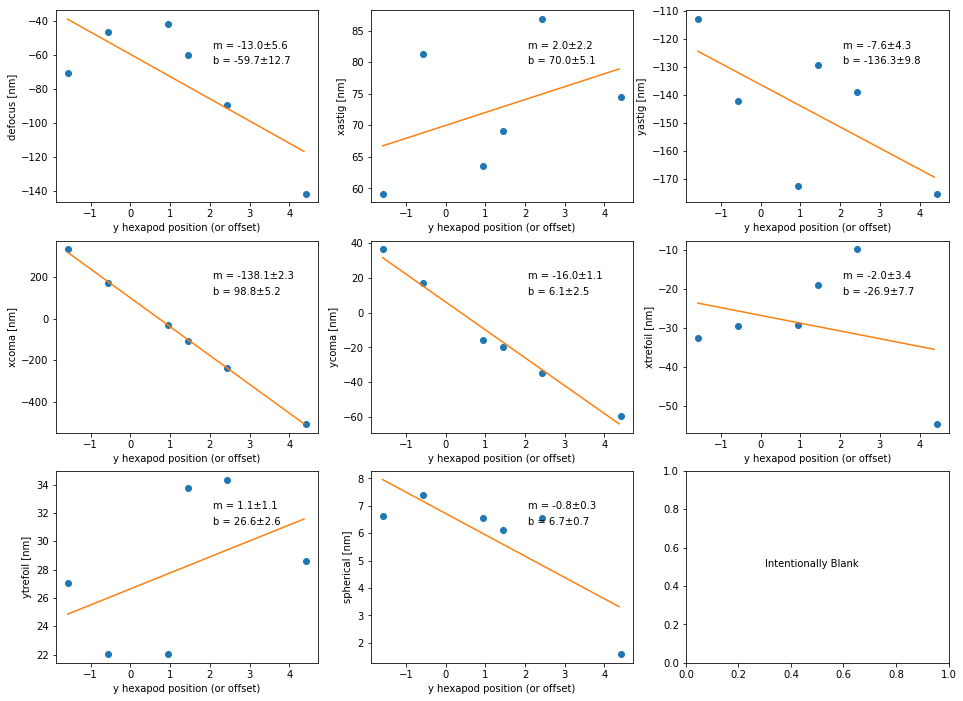

In [48]:
# using the variable axs for multiple Axes
nx=3; ny=3
fig, axs = plt.subplots(3, 3)
fig.set_size_inches(16, 12, forward=True)
count=0
motion_key=axis
zern_keys = df3.keys()[18:29]
for i in range(nx):
    for j in range(ny):
        if count>len(zern_keys)-1:
            axs[i, j].annotate(f'Intentionally Blank',(0.3,0.5), xycoords=xycoords)
            continue
        zern_key=zern_keys[count]
        xdata=df3[motion_key][inds]
        ydata=df3[zern_key][inds]

        axs[i, j].plot(xdata,ydata,'o')
        x=np.arange(np.min(xdata), np.max(xdata), np.abs(np.max(xdata) - np.min(xdata))/100 )
        popt,pcov = curve_fit(line, xdata, ydata)
        perr = np.sqrt(np.diag(pcov))

        axs[i, j].plot(x,line(x, *popt))
        tmp=zern_key
        axs[i, j].set_ylabel(f"{zern_key.split('_')[1]} [nm]")
        axs[i, j].set_xlabel(motion_key+' hexapod position (or offset)')
        xpos=0.6; ypos=0.8 ; xycoords='axes fraction'
        axs[i, j].annotate(f'm = {popt[1]:0.1f}\u00B1{perr[1]:0.1f}',(xpos,ypos), xycoords=xycoords)
        axs[i, j].annotate(f'b = {popt[0]:0.1f}\u00B1{perr[0]:0.1f}',(xpos,ypos-0.08), xycoords=xycoords)
        
        count+=1


In [ ]:
xdata=df3[motion_key][inds]

In [ ]:
motion_key